# 폐렴진단 모델 추론

In [ ]:
# tensorflow 버전 확인
import tensorflow as tf
tf.__version__

'2.2.0'

In [1]:
# 내 구글 드라이버에 연동
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# 필요한 패키지와 모듈을 불러옴
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# 하이퍼파라메터 설정
image_height = 150  # 이미지 높이
image_width = 150   # 이미지 넓이
batch_size = 10     # batch size
no_of_epochs  = 30  # training 횟수

In [4]:
# 저장해 뒀던 모델을 불러옵니다.

new_model = load_model('gdrive/My Drive/CV/Diagnose Pneumonia/diagnose_pneumonia_model.h5')
new_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 146, 146, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 73, 73, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 73, 73, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 71, 71, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 69, 69, 64)        36928     
                                                        

In [5]:
# ImageDataGenerator 클래스를 통해 train_datagen 인스턴스를 만듭니다.
# train_datagen = ImageDataGenerator(rescale=1./255,     # 픽셀 값을 0~1 범위로 변환
#                                    rotation_range=15,  # 15도까지 회전
#                                    shear_range=0.2,    # 20%까지 기울임
#                                    zoom_range=0.2      # 20%까지 확대
#                                    )

In [6]:
# ImageDataGenerator 클래스를 통해 val_datagen 인스턴스를 만듭니다.
val_datagen = ImageDataGenerator(rescale=1./255)       # 픽셀 값을 0~1 범위로 변환

In [7]:
# train_datagen 인스턴스를 통해 trin dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 training_set 객체를 생성한다.
# training_set = train_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/train',
#                                                  target_size=(image_width, image_height),
#                                                  batch_size=batch_size,
#                                                  class_mode='binary')

Found 5216 images belonging to 2 classes.


In [8]:
# val_datagen 인스턴스를 통해 test dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 test_set 객체를 생성한다.
test_set = val_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/test',
                                            target_size=(image_width, image_height),
                                            batch_size=batch_size,
                                            class_mode='binary')

Found 624 images belonging to 2 classes.


In [9]:
# val_datagen 인스턴스를 통해 val dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 val_set 객체를 생성한다.
val_set = val_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/val',
                                            target_size=(image_width, image_height),
                                            batch_size=1,
                                            shuffle=False,
                                            class_mode='binary')

Found 16 images belonging to 2 classes.


In [10]:
# model evaluate(모델을 평가해 봅니다)
score = new_model.evaluate(test_set, steps=624//batch_size, verbose=1)
print('Val loss:', score[0])
print('Val accuracy:', score[1]*100)

62/62 [==============================] - 72s 1s/step - loss: 0.2335 - accuracy: 0.9113
Val loss: 0.23350019752979279
Val accuracy: 91.12903475761414


In [11]:
# val_set 이 만들어낸 이미지를 우리가 만든 모델을 통해 분류 예측해 봅니다.
predictions = new_model.predict(val_set, steps=16, verbose=1)

16/16 [==============================] - 5s 274ms/step


In [12]:
# predictions shape 확인
predictions.shape

(16, 1)

In [13]:
# 예측결과 확인
predictions

array([[0.7094598 ],
       [0.5348589 ],
       [0.23154849],
       [0.83332103],
       [0.98341817],
       [0.9487347 ],
       [0.3363725 ],
       [0.02327376],
       [0.99761   ],
       [0.99450207],
       [0.9044902 ],
       [0.90861344],
       [0.97572815],
       [0.994443  ],
       [0.98599225],
       [0.98664063]], dtype=float32)

In [14]:
# val_set 이 만들어 내는 이미지의 클래스 인덱스가 무엇인지 확인해 본다.
print(val_set.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


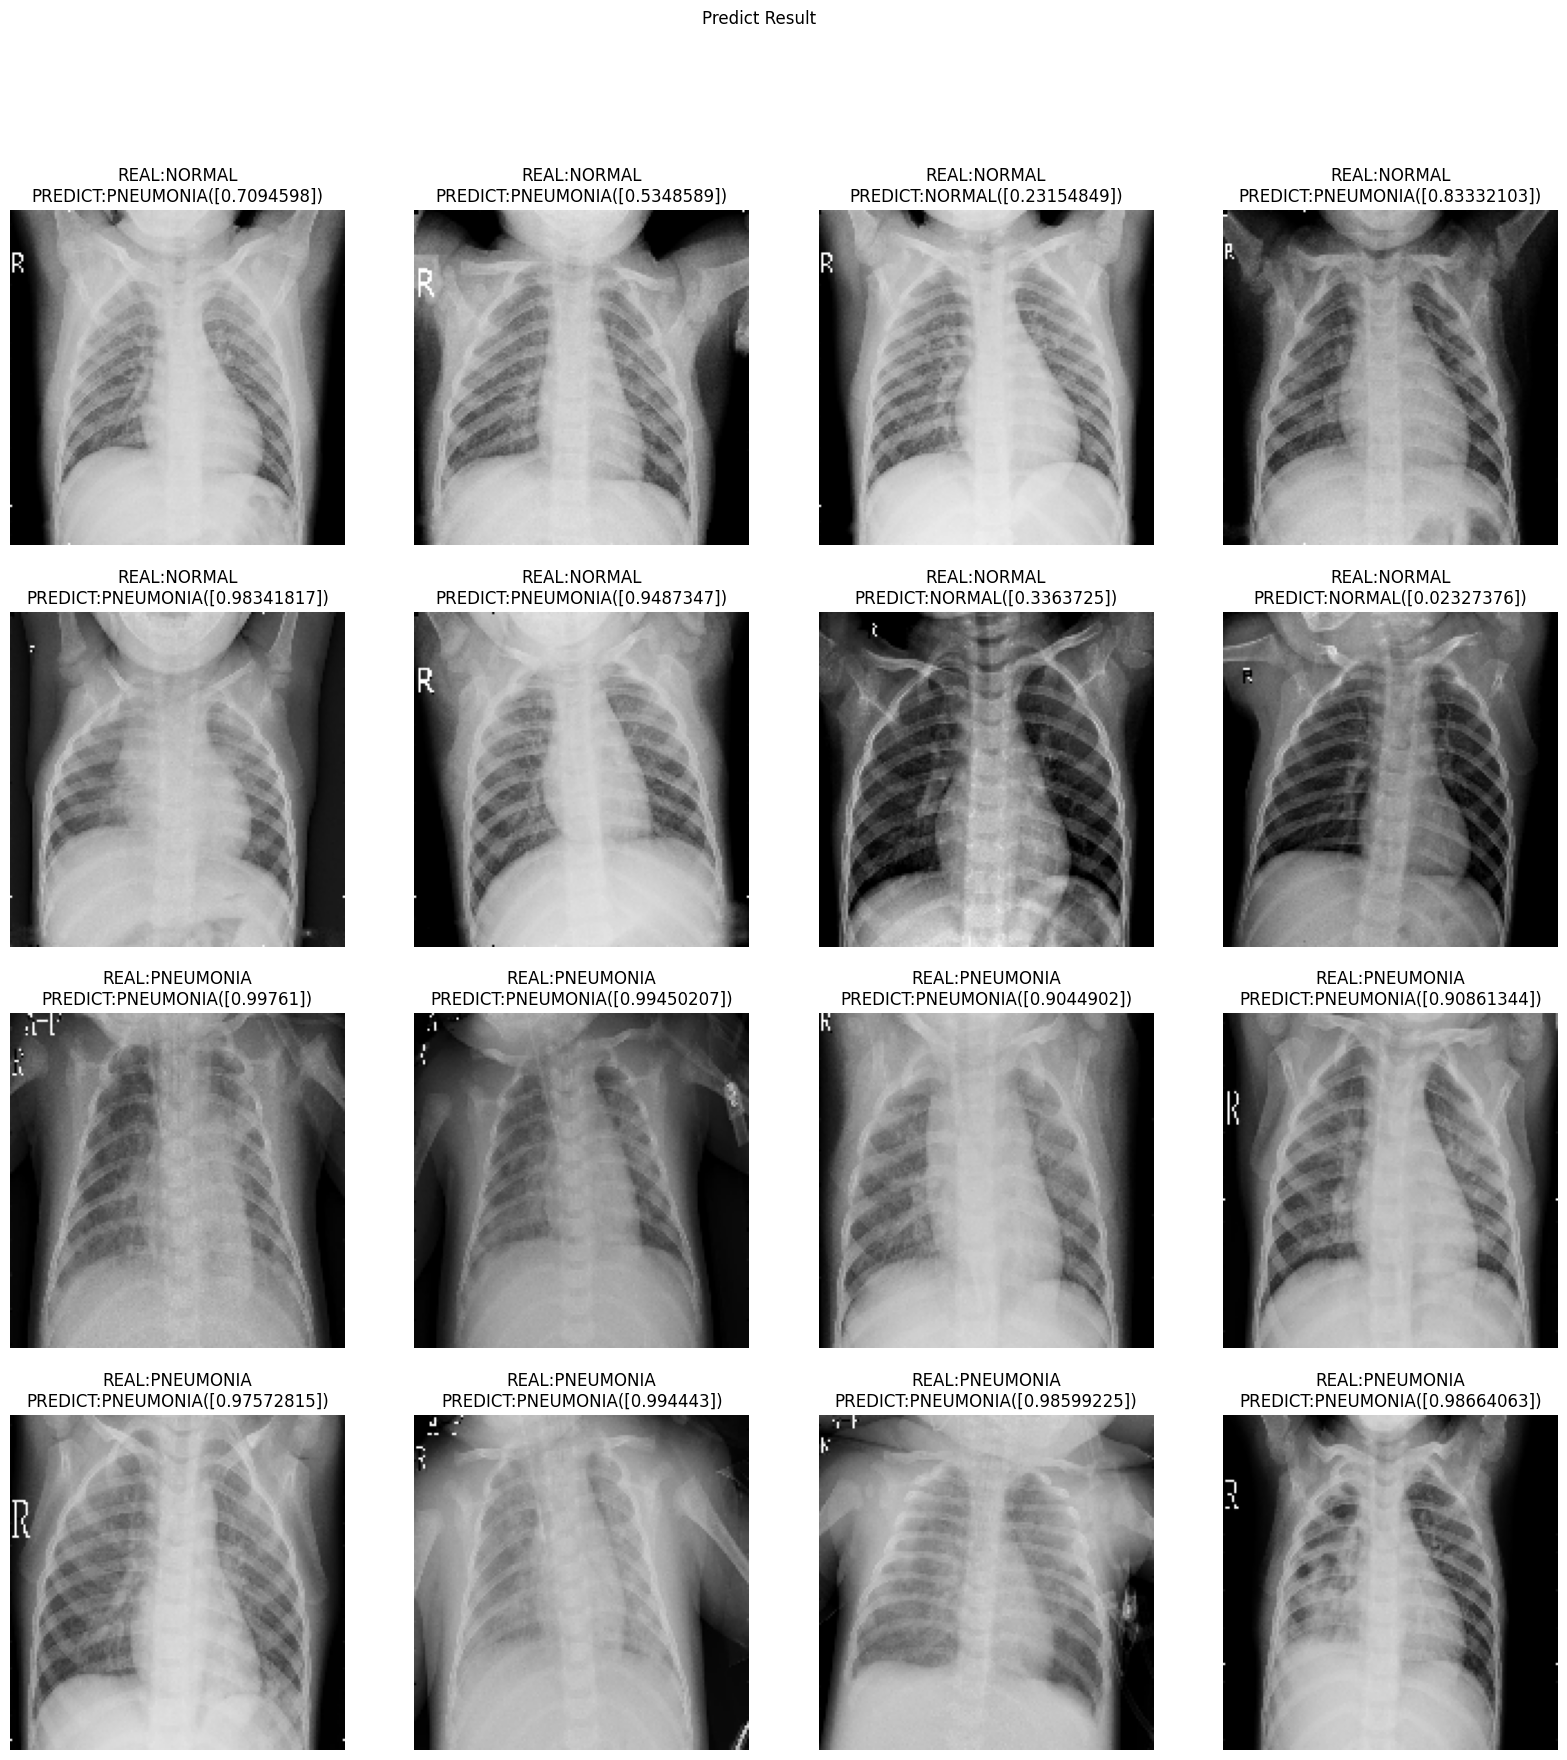

In [15]:
# Predict Result(val_set 가 만들어 낸 이미지를 우리가 만든 모델을 통해 예측한 결과를 보여줍니다.)
f,ax = plt.subplots(4,4,figsize=(20,20))

for i in range(len(predictions)):
    image, label = val_set.next()                                  # val_set 이 만들어 낸 이미지를 하나씩 꺼내온다
    real_class = 'NORMAL' if int(label) == 0 else 'PNEUMONIA'      # val_set 이 만들어 낸 이미지의 label name 을 가져옴
    ax[i//4,i%4].imshow(image[0])                                  # val_set 이 만들어 낸 이미지를 보여줌
    ax[i//4,i%4].axis('off')

    pred_class = 'PNEUMONIA' if predictions[i] > 0.5 else 'NORMAL' # val_set 이 만들어 낸 이미지를 모델을 통해 예측한 결과 값의 label name
    pred_prob = predictions[i]                                     # val_set 이 만들어 낸 이미지를 모델을 통해 예측한 결과(확률값)
    ax[i//4,i%4].set_title('REAL:' + real_class + '\nPREDICT:' + pred_class + '(' + str(pred_prob) + ')')   # title 에 실제값과 모델에 의해 예측된 예측값을 함께 보여준다.

f.suptitle('Predict Result')

plt.show()